# Chapter 09: The Graphics Pipeline

Source orientation: printed pages 177-204; physical PDF pages 194-221. This notebook uses the source span only to choose the mathematical coverage: object-order rendering, the vertex/raster/fragment/blending stages, triangle rasterization, barycentric interpolation, perspective-correct attributes, clipping, z-buffering, shading frequency, antialiasing, and culling. The prose, code, diagrams, and checks are original course material.

## Chapter question

How does an object-order renderer turn transformed triangles into stable pixels, depths, and colors?

The graphics pipeline is a contract between stages. Vertex processing produces screen-space vertices and attributes. Rasterization enumerates covered pixel centers and interpolates attributes. Fragment processing shades or otherwise modifies those fragments. Blending and depth tests decide which fragment contributes to the framebuffer. This notebook makes each contract inspectable with small arrays rather than treating the pipeline as hardware folklore.

## Translation guide

- **Primitive**: the directly rasterized object; this chapter mostly uses triangles.
- **Fragment**: the candidate contribution for one pixel, carrying interpolated attributes such as color, depth, texture coordinates, or normals.
- **Barycentric coordinates**: weights that decide whether a pixel center is inside a triangle and how vertex attributes interpolate.
- **Perspective-correct interpolation**: interpolate `u/w`, `v/w`, and `1/w`, then divide to recover `(u,v)`.
- **Clipping**: trim primitives before rasterization when they leave the view volume or cross the eye plane.
- **Z-buffer**: a per-pixel depth memory that lets nearer fragments replace farther fragments.
- **Culling**: discard work that cannot affect the image, such as back-facing triangles or objects wholly outside a view plane.

## Visual storyboard and library routing

| Order | Artifact | Concept | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | `graphics-pipeline-stage-flow.png` | pipeline stages | stage graph | Matplotlib | what each stage consumes and emits | stage order and data contract |
| 2 | `triangle-barycentric-raster-grid.png` | triangle rasterization | pixel-center grid | NumPy + Matplotlib | covered centers and barycentric weights | weights sum to one; inside count |
| 3 | `edge-ownership-shared-triangles.png` | shared-edge tie rule | adjacent triangles | Matplotlib | no holes and no double draws along a shared edge | exclusive edge ownership |
| 4 | `perspective-correct-interpolation.png` | attribute interpolation | line/triangle diagnostic | NumPy + Matplotlib | screen-linear error vs corrected value | corrected residual below naive residual |
| 5 | `clipping-before-rasterization.png` | view-volume clipping | polygon clipped to unit square | Matplotlib | why behind/outside primitives must be trimmed | clipped vertices satisfy bounds |
| 6 | `z-buffer-depth-precision.png` | depth tests and nonlinear precision | two-triangle z-buffer and bin plot | NumPy + Matplotlib | nearest fragment wins; far bins get coarser | z-buffer visibility and monotonic bins |
| 7 | `shading-frequency-antialiasing.png` | vertex vs fragment shading and supersampling | image panels | NumPy + Matplotlib | interpolation artifacts and edge smoothing | supersampling gives fractional coverage |
| 8 | `culling-decision-lab.html` | view/backface culling | interactive Plotly lab | Plotly | how plane distance and normal sign reject work | conservative sphere/backface checks |

The chapter is complete when the reader can trace one triangle from vertex data to pixel decisions and can identify which failures belong to rasterization, interpolation, clipping, depth, shading frequency, antialiasing, or culling.


In [1]:
from pathlib import Path
import math
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon, Rectangle
import numpy as np
import plotly.graph_objects as go

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table_csv
from utils.notebook_checks import assert_nonblank_image

CHAPTER = 9
TITLE = "The Graphics Pipeline"
UNIT = f"chapter-{CHAPTER:02d}"
SOURCE_SPAN = "printed pages 177-204; physical PDF pages 194-221"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
for child in ["figures", "html", "tables", "checks"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 170, "font.size": 10})
COLORS = {
    "blue": "#2b6cb0",
    "teal": "#008080",
    "orange": "#d97706",
    "red": "#c53030",
    "green": "#2f855a",
    "purple": "#6b46c1",
    "gray": "#4a5568",
    "light": "#edf2f7",
}
image_paths = []
html_paths = []
table_paths = []
check_paths = []
checks = {}

def remember(path, kind):
    if kind == "image": image_paths.append(path)
    elif kind == "html": html_paths.append(path)
    elif kind == "table": table_paths.append(path)
    elif kind == "check": check_paths.append(path)
    return path

def rel_book(path):
    p = Path(path)
    if not p.is_absolute() and p.parts and p.parts[0] == "artifacts":
        return p.as_posix()
    try:
        return p.resolve().relative_to(BOOK_ROOT).as_posix()
    except ValueError:
        return p.as_posix()

def edge_function(a, b, p):
    a = np.asarray(a, float); b = np.asarray(b, float); p = np.asarray(p, float)
    return (p[...,0] - a[0]) * (b[1] - a[1]) - (p[...,1] - a[1]) * (b[0] - a[0])

def barycentric(p, tri):
    p = np.asarray(p, float)
    a, b, c = np.asarray(tri, float)
    area = edge_function(a, b, c)
    alpha = edge_function(b, c, p) / area
    beta = edge_function(c, a, p) / area
    gamma = edge_function(a, b, p) / area
    return np.stack([alpha, beta, gamma], axis=-1)

def inside_triangle(p, tri, eps=1e-12):
    bc = barycentric(p, tri)
    return np.all(bc >= -eps, axis=-1), bc

def top_left_edge(a, b):
    dx, dy = b[0] - a[0], b[1] - a[1]
    return (dy < 0) or (dy == 0 and dx > 0)

def inside_triangle_top_left(p, tri):
    tri = np.asarray(tri, float)
    # Orient CCW for consistent edge signs.
    if edge_function(tri[0], tri[1], tri[2]) < 0:
        tri = tri[[0,2,1]]
    values = np.array([edge_function(tri[i], tri[(i+1)%3], p) for i in range(3)])
    inclusive = np.array([top_left_edge(tri[i], tri[(i+1)%3]) for i in range(3)])
    keep = []
    for value, inc in zip(values, inclusive):
        keep.append(value < 0 if not inc else value <= 0)
    # edge_function sign here is negative for inside with the chosen formula/orientation.
    return bool(np.all(keep))

def style_2d(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, color="#e2e8f0", lw=0.8)


## 1. Pipeline stages and data contracts

The chapter organizes object-order rendering as a sequence of stages. Vertices enter the pipeline with positions and attributes. Vertex processing transforms them to screen space and may compute per-vertex quantities. Rasterization turns primitives into fragments. Fragment processing computes per-fragment color or other values. Blending and depth tests update the framebuffer.

The important thing to inspect is not merely the list of boxes. It is the data contract between boxes. A rasterizer cannot do perspective-correct texture mapping unless the vertex stage passes the right homogeneous quantities. A depth test cannot choose a winner unless the fragment carries a comparable depth value. A culling test is valuable only when it is cheaper than the work it discards.


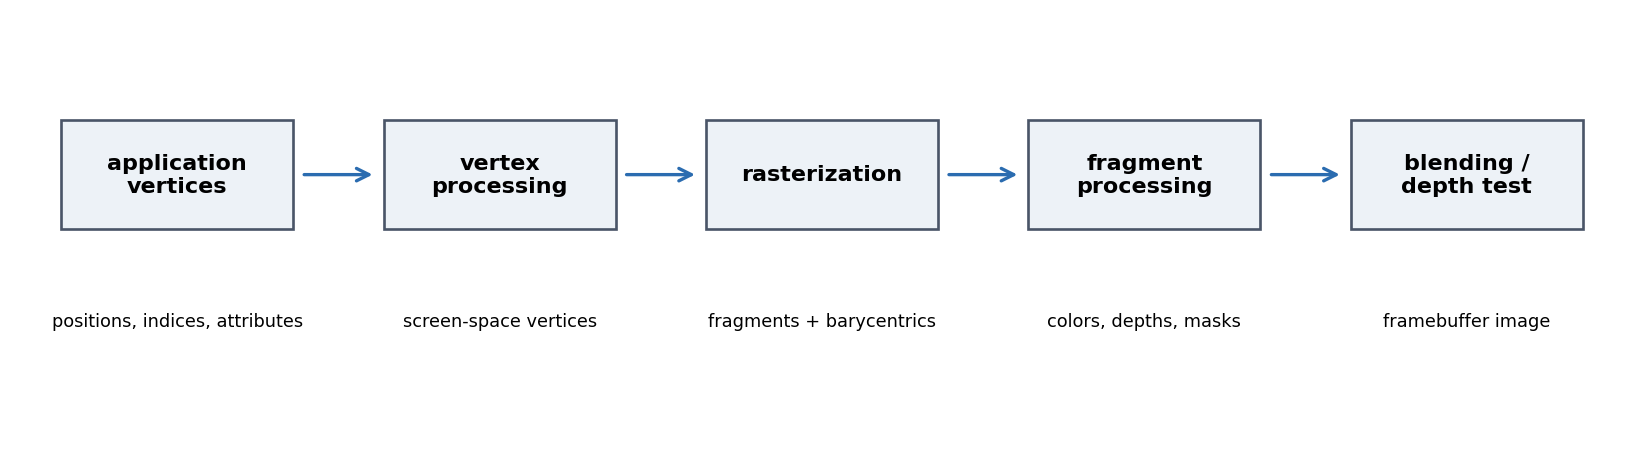

In [2]:
stages = [
    ("application\nvertices", "positions, indices, attributes"),
    ("vertex\nprocessing", "screen-space vertices"),
    ("rasterization", "fragments + barycentrics"),
    ("fragment\nprocessing", "colors, depths, masks"),
    ("blending /\ndepth test", "framebuffer image"),
]
fig, ax = plt.subplots(figsize=(13.0, 3.6))
ax.axis("off")
ax.set_xlim(-0.5, len(stages)-0.5)
ax.set_ylim(-0.7, 1.0)
for i, (stage, contract) in enumerate(stages):
    ax.add_patch(Rectangle((i-0.36, 0.18), 0.72, 0.42, facecolor=COLORS["light"], edgecolor=COLORS["gray"], lw=1.2))
    ax.text(i, 0.39, stage, ha="center", va="center", weight="bold")
    ax.text(i, -0.14, contract, ha="center", va="top", fontsize=8)
    if i < len(stages)-1:
        ax.add_patch(FancyArrowPatch((i+0.38, 0.39), (i+0.62, 0.39), arrowstyle="->", mutation_scale=14, lw=1.5, color=COLORS["blue"]))
checks["pipeline_stage_count"] = len(stages)
checks["pipeline_contracts_named"] = True
pipeline_path = remember(save_matplotlib(fig, UNIT, "graphics-pipeline-stage-flow.png"), "image")
plt.close(fig)
display_artifact(pipeline_path, width=900)


## 2. Triangle rasterization: pixel centers and barycentric weights

Rasterization has two jobs: enumerate covered pixels and interpolate attributes. The standard triangle test evaluates pixel centers. If the center is inside the triangle, a fragment is emitted and its attributes are computed from barycentric weights. For vertex colors, this is Gouraud interpolation.

The grid below shows pixel centers, covered fragments, and a color made directly from barycentric coordinates. The numerical checks verify the defining property of barycentric coordinates: the three weights sum to one, and the interpolated color is a convex combination at covered pixels.


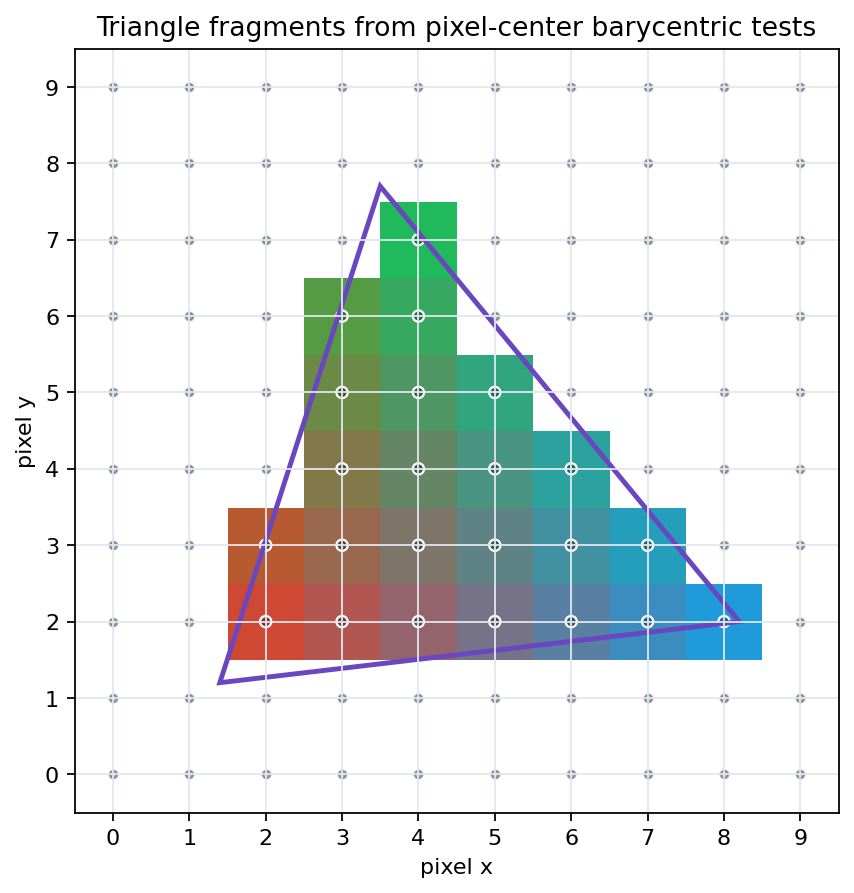

In [3]:
tri = np.array([[1.4, 1.2], [8.2, 2.0], [3.5, 7.7]])
colors = np.array([[0.95, 0.2, 0.15], [0.1, 0.62, 0.88], [0.12, 0.75, 0.3]])
xs = np.arange(0, 10)
ys = np.arange(0, 10)
centers = np.array([[x, y] for y in ys for x in xs], dtype=float)
inside, weights = inside_triangle(centers, tri)
fragment_colors = weights @ colors
img = np.ones((10, 10, 3))
for (x, y), keep, col in zip(centers.astype(int), inside, fragment_colors):
    if keep:
        img[y, x] = np.clip(col, 0, 1)
checks["raster_fragment_count"] = int(inside.sum())
checks["barycentric_weight_sum_error"] = float(np.max(np.abs(weights[inside].sum(axis=1) - 1)))
checks["barycentric_color_range_ok"] = bool(np.all((fragment_colors[inside] >= -1e-12) & (fragment_colors[inside] <= 1 + 1e-12)))

fig, ax = plt.subplots(figsize=(6.4, 6.2))
ax.imshow(img, origin="lower", extent=(-0.5, 9.5, -0.5, 9.5))
ax.scatter(centers[:,0], centers[:,1], s=12, color="#1a202c", alpha=0.35)
ax.scatter(centers[inside,0], centers[inside,1], s=26, facecolors="none", edgecolors="white", lw=1.0)
ax.add_patch(Polygon(tri, fill=False, edgecolor=COLORS["purple"], lw=2.2))
ax.set_xticks(range(10)); ax.set_yticks(range(10))
style_2d(ax, "Triangle fragments from pixel-center barycentric tests", "pixel x", "pixel y")
ax.set_aspect("equal")
raster_path = remember(save_matplotlib(fig, UNIT, "triangle-barycentric-raster-grid.png"), "image")
plt.close(fig)
display_artifact(raster_path, width=650)


## 3. Shared edges need an ownership rule

Adjacent triangles share edges. If both triangles draw a pixel whose center lies exactly on the shared edge, transparent or order-dependent rendering can double-count it. If neither triangle draws it, a hole appears. A deterministic edge convention assigns exact edge cases to exactly one triangle. Hardware conventions vary in detail, but the purpose is the same: make shared-edge behavior reproducible.

The finite test below uses two triangles that form a square and a top-left style tie rule. The check records that every center in the square is covered exactly once.


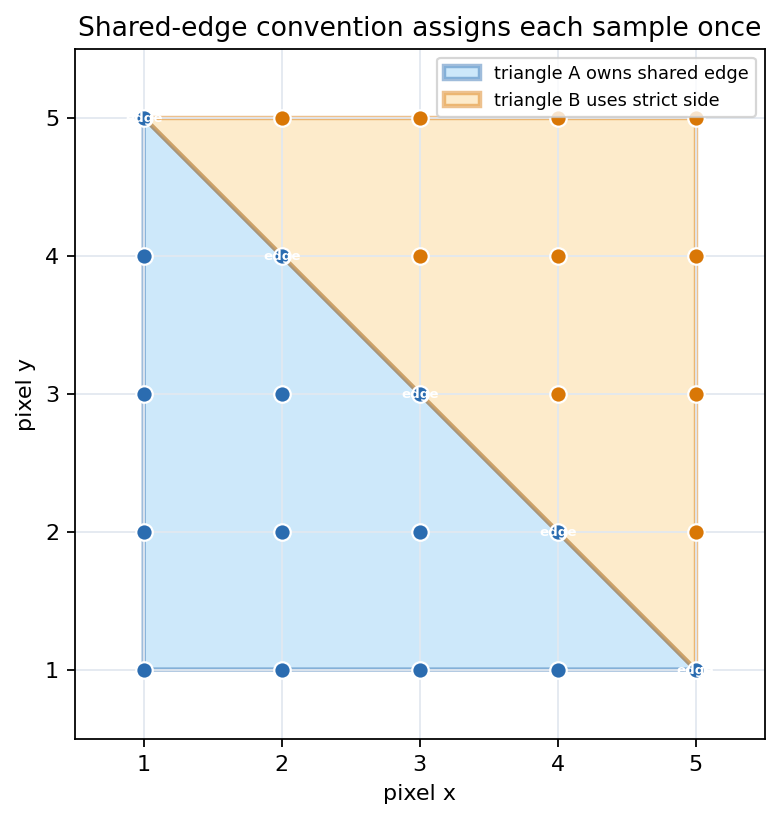

In [4]:
tri_a = np.array([[1,1], [5,1], [1,5]], dtype=float)
tri_b = np.array([[5,1], [5,5], [1,5]], dtype=float)
grid = np.array([[x, y] for y in range(1,6) for x in range(1,6)], dtype=float)
# This square is split by the shared diagonal x + y = 6. A deterministic tie rule
# awards exact shared-edge samples to triangle A and strict samples above the edge to B.
inside_square = (grid[:,0] >= 1) & (grid[:,0] <= 5) & (grid[:,1] >= 1) & (grid[:,1] <= 5)
cover_a = inside_square & (grid[:,0] + grid[:,1] <= 6)
cover_b = inside_square & (grid[:,0] + grid[:,1] > 6)
coverage = cover_a.astype(int) + cover_b.astype(int)
checks["shared_edge_no_double_draws"] = bool(np.all(coverage <= 1))
checks["shared_edge_no_holes_in_square_samples"] = bool(np.all(coverage == 1))
checks["shared_edge_exactly_once_count"] = int(np.sum(coverage == 1))
checks["shared_edge_samples_owned_by_a"] = int(np.sum(cover_a & (grid[:,0] + grid[:,1] == 6)))

fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.add_patch(Polygon(tri_a, closed=True, facecolor="#90cdf4", edgecolor=COLORS["blue"], alpha=0.45, lw=2, label="triangle A owns shared edge"))
ax.add_patch(Polygon(tri_b, closed=True, facecolor="#fbd38d", edgecolor=COLORS["orange"], alpha=0.45, lw=2, label="triangle B uses strict side"))
for p, ca, cb in zip(grid, cover_a, cover_b):
    color = COLORS["blue"] if ca else COLORS["orange"] if cb else COLORS["red"]
    ax.scatter([p[0]], [p[1]], s=55, color=color, edgecolor="white", zorder=3)
    if ca and p[0] + p[1] == 6:
        ax.text(p[0], p[1], "edge", ha="center", va="center", color="white", fontsize=6, weight="bold")
ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1,6)); ax.set_yticks(range(1,6))
ax.set_aspect("equal")
style_2d(ax, "Shared-edge convention assigns each sample once", "pixel x", "pixel y")
ax.legend(fontsize=8, loc="upper right")
edge_path = remember(save_matplotlib(fig, UNIT, "edge-ownership-shared-triangles.png"), "image")
plt.close(fig)
display_artifact(edge_path, width=650)


## 4. Perspective-correct interpolation repairs screen-linear attributes

After perspective projection, screen-space barycentric weights are not the same as the original 3D interpolation weights. Interpolating texture coordinates directly in screen space produces visible warping. The chapter's fix is to interpolate `u/w`, `v/w`, and `1/w`; the original coordinate is recovered by division.

The diagnostic uses one line segment because the algebra is easier to see. The same idea is applied across triangles. The corrected curve matches the world-linear attribute, while the naive screen-linear interpolation drifts.


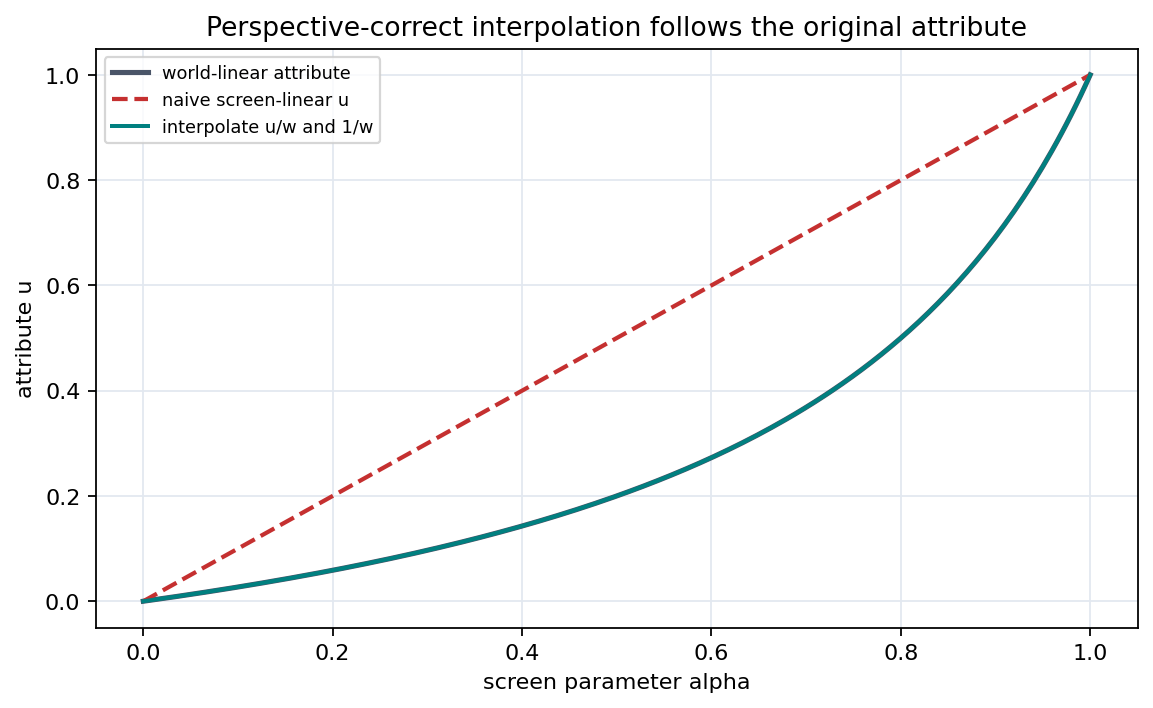

In [5]:
# Two endpoints before homogeneous division. w mimics depth-dependent homogeneous scale.
u0, u1 = 0.0, 1.0
w0, w1 = 1.0, 4.0
alpha = np.linspace(0, 1, 200)  # screen-space parameter
# Recover pre-projection line parameter from alpha and homogeneous endpoint weights.
t = (w0 * alpha) / (w1 + alpha * (w0 - w1))
true_u = u0 + t * (u1 - u0)
naive_u = u0 + alpha * (u1 - u0)
interp_u_over_w = (1 - alpha) * (u0 / w0) + alpha * (u1 / w1)
interp_inv_w = (1 - alpha) * (1 / w0) + alpha * (1 / w1)
corrected_u = interp_u_over_w / interp_inv_w
checks["perspective_correct_max_error"] = float(np.max(np.abs(corrected_u - true_u)))
checks["naive_screen_interp_max_error"] = float(np.max(np.abs(naive_u - true_u)))
checks["perspective_correct_improves_error"] = bool(checks["perspective_correct_max_error"] < 1e-12 and checks["naive_screen_interp_max_error"] > 0.1)

fig, ax = plt.subplots(figsize=(8.4, 4.7))
ax.plot(alpha, true_u, color=COLORS["gray"], lw=2.3, label="world-linear attribute")
ax.plot(alpha, naive_u, color=COLORS["red"], ls="--", lw=1.9, label="naive screen-linear u")
ax.plot(alpha, corrected_u, color=COLORS["teal"], lw=1.8, label="interpolate u/w and 1/w")
style_2d(ax, "Perspective-correct interpolation follows the original attribute", "screen parameter alpha", "attribute u")
ax.legend(fontsize=8)
interp_path = remember(save_matplotlib(fig, UNIT, "perspective-correct-interpolation.png"), "image")
plt.close(fig)
display_artifact(interp_path, width=760)


## 5. Clipping protects rasterization from impossible primitives

Simply projecting and rasterizing every transformed primitive is unsafe. Geometry can lie outside the view volume or cross the eye plane, producing nonsensical screen coordinates after homogeneous division. Clipping replaces a primitive by the portion inside a view region before rasterization.

The example clips a polygon against the canonical square. It is not an industrial-strength clipper, but it exposes the core invariant: after clipping, every vertex satisfies the view bounds and the new boundary vertices are intersections with clipping planes.


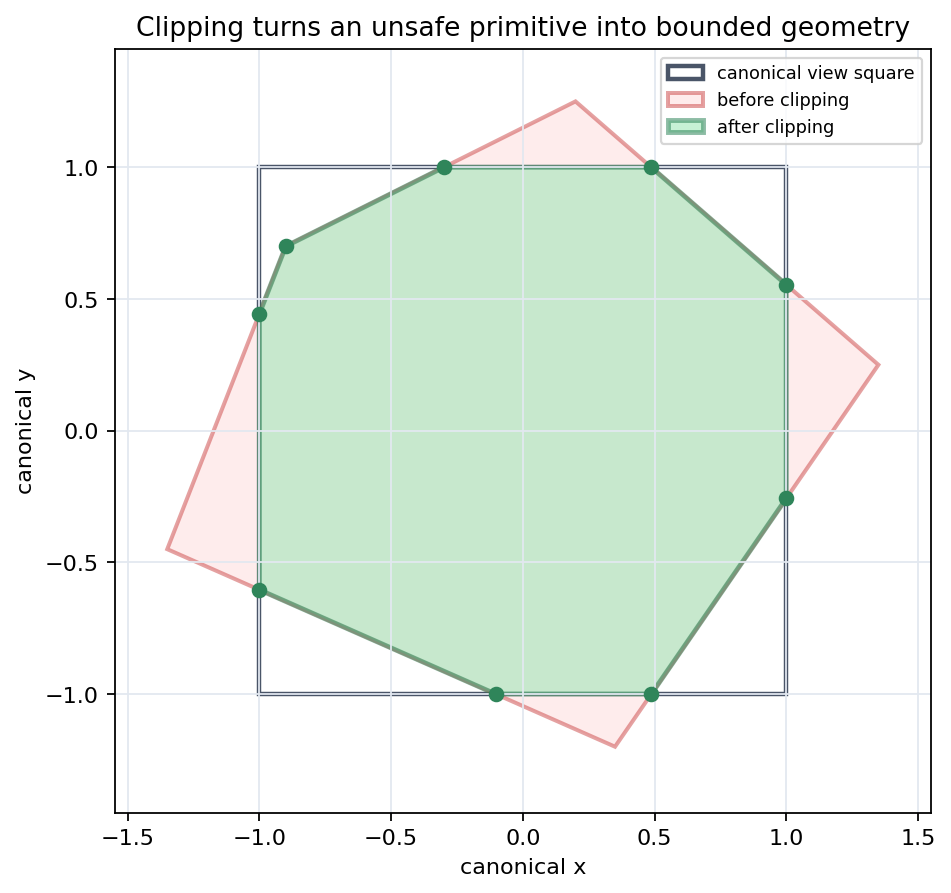

In [6]:
poly = np.array([[-1.35, -0.45], [0.35, -1.2], [1.35, 0.25], [0.2, 1.25], [-0.9, 0.7]])

def clip_polygon_halfspace(points, axis, bound, keep_less=True):
    out = []
    pts = list(points)
    for a, b in zip(pts, pts[1:] + pts[:1]):
        fa = a[axis] - bound
        fb = b[axis] - bound
        ina = fa <= 1e-12 if keep_less else fa >= -1e-12
        inb = fb <= 1e-12 if keep_less else fb >= -1e-12
        if ina and inb:
            out.append(b)
        elif ina and not inb or (not ina and inb):
            denom = b[axis] - a[axis]
            s = (bound - a[axis]) / denom
            inter = a + s * (b - a)
            out.append(inter)
            if inb:
                out.append(b)
    return np.array(out) if out else np.empty((0,2))

clipped = poly.copy()
for axis, bound, keep_less in [(0, -1, False), (0, 1, True), (1, -1, False), (1, 1, True)]:
    clipped = clip_polygon_halfspace(clipped, axis, bound, keep_less)
checks["clipped_vertex_count"] = int(len(clipped))
checks["clipped_all_inside_unit_square"] = bool(np.all(clipped <= 1 + 1e-12) and np.all(clipped >= -1 - 1e-12))

fig, ax = plt.subplots(figsize=(6.6, 6.2))
ax.add_patch(Rectangle((-1,-1), 2, 2, fill=False, edgecolor=COLORS["gray"], lw=2, label="canonical view square"))
ax.add_patch(Polygon(poly, closed=True, facecolor="#fed7d7", edgecolor=COLORS["red"], alpha=0.45, lw=1.8, label="before clipping"))
ax.add_patch(Polygon(clipped, closed=True, facecolor="#9ae6b4", edgecolor=COLORS["green"], alpha=0.55, lw=2.2, label="after clipping"))
ax.scatter(clipped[:,0], clipped[:,1], color=COLORS["green"], zorder=3)
ax.set_aspect("equal")
ax.set_xlim(-1.55, 1.55); ax.set_ylim(-1.45, 1.45)
style_2d(ax, "Clipping turns an unsafe primitive into bounded geometry", "canonical x", "canonical y")
ax.legend(fontsize=8)
clip_path = remember(save_matplotlib(fig, UNIT, "clipping-before-rasterization.png"), "image")
plt.close(fig)
display_artifact(clip_path, width=680)


## 6. Z-buffering chooses the nearest fragment, but precision is uneven

The z-buffer stores one depth value per pixel. When two fragments cover the same pixel, the nearer fragment wins and updates both color and depth. This makes object drawing order much less important than in a pure painter's algorithm.

Perspective depth is nonlinear, so fixed-depth bins do not correspond to equal world-space distances. The source chapter points out that this must be handled carefully: moving the near plane too close can spend too much precision near the eye and leave coarse bins far away. The right panel shows the approximate world-space bin width growing with distance.


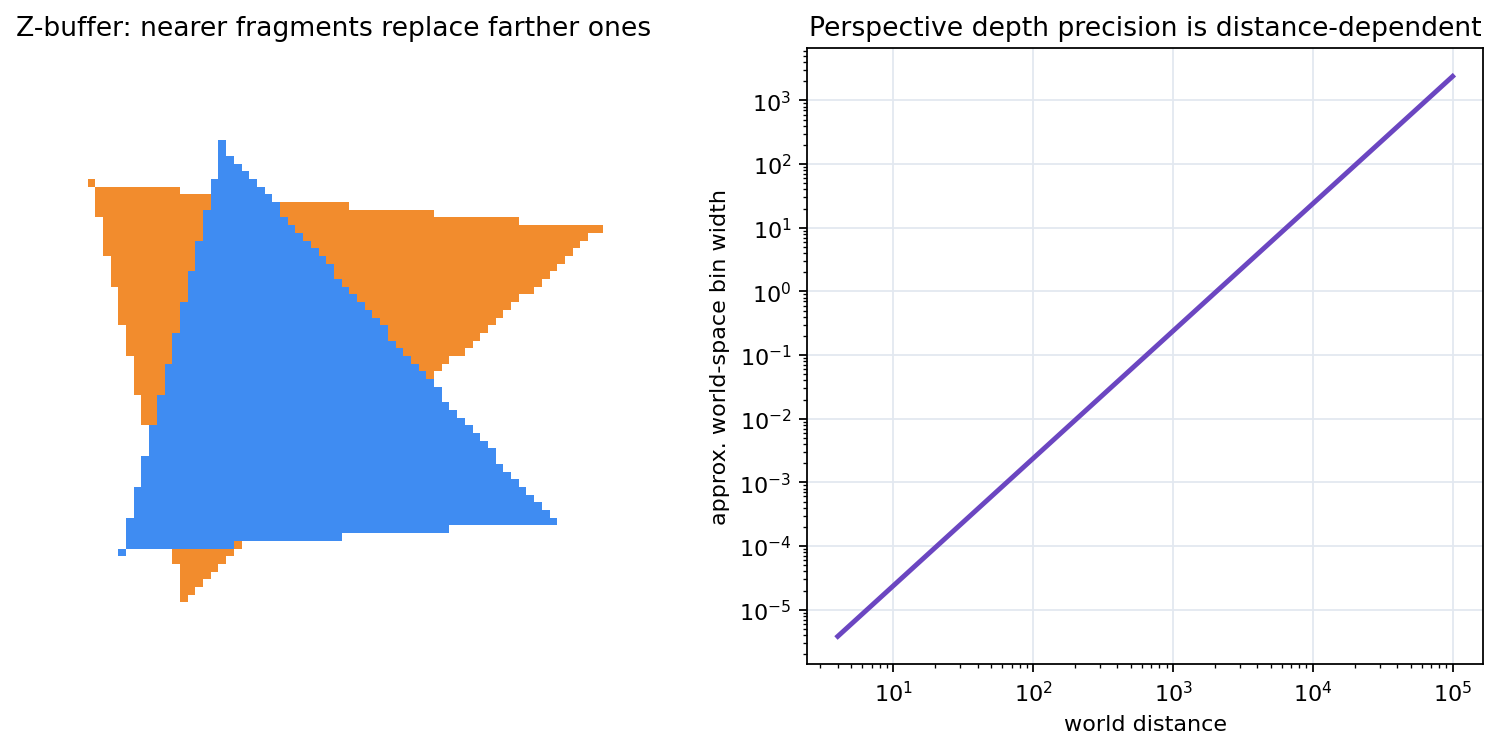

In [7]:
W = H = 80
Y, X = np.mgrid[0:H, 0:W]
tri_front = np.array([[12, 14], [68, 18], [25, 67]], dtype=float)
tri_back = np.array([[20, 8], [74, 56], [8, 62]], dtype=float)
pts = np.c_[X.ravel(), Y.ravel()]
inside_front, wf = inside_triangle(pts, tri_front)
inside_back, wb = inside_triangle(pts, tri_back)
z_front = (0.25 + 0.35 * wf[:,1] + 0.08 * wf[:,2]).reshape(H, W)
z_back = (0.55 + 0.22 * wb[:,0] + 0.10 * wb[:,2]).reshape(H, W)
color = np.ones((H, W, 3))
depth = np.ones((H, W)) * np.inf
front_mask = inside_front.reshape(H, W)
back_mask = inside_back.reshape(H, W)
# Draw back first, then front; z-test should still make nearer front win where appropriate.
color[back_mask] = np.array([0.95, 0.55, 0.18]); depth[back_mask] = z_back[back_mask]
replace = front_mask & (z_front < depth)
color[replace] = np.array([0.25, 0.55, 0.95]); depth[replace] = z_front[replace]
checks["zbuffer_front_replacements"] = int(replace.sum())
checks["zbuffer_visible_pixels"] = int(np.isfinite(depth).sum())
checks["zbuffer_front_wins_overlap"] = bool(np.all(depth[front_mask & back_mask] == z_front[front_mask & back_mask]))

near_dist, far_dist, bits = 4.0, 100000.0, 20
B = 2 ** bits
z_world = np.geomspace(near_dist, far_dist, 260)
# Approximate world bin size from source-style derivative: grows roughly with distance squared.
bin_width = (z_world**2 / (near_dist * far_dist)) * ((far_dist - near_dist) / B)
checks["zbuffer_bin_width_increases"] = bool(bin_width[-1] > bin_width[0] * 1000)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))
axes[0].imshow(color, origin="lower")
axes[0].set_title("Z-buffer: nearer fragments replace farther ones")
axes[0].axis("off")
axes[1].loglog(z_world, bin_width, color=COLORS["purple"], lw=2.2)
style_2d(axes[1], "Perspective depth precision is distance-dependent", "world distance", "approx. world-space bin width")
zbuf_path = remember(save_matplotlib(fig, UNIT, "z-buffer-depth-precision.png"), "image")
plt.close(fig)
display_artifact(zbuf_path, width=860)


## 7. Shading frequency and antialiasing are sampling decisions

The pipeline can shade per vertex and interpolate colors, or shade per fragment after interpolating geometric attributes. Per-vertex shading is cheaper but can miss small highlights inside large primitives. Per-fragment shading is more expensive but samples the lighting function at the pixels that will actually be displayed.

Aliasing is another sampling decision. Standard rasterization asks only whether a pixel center lies inside the primitive. Supersampling estimates partial coverage by testing several points inside each pixel and averaging. The output is less jagged because the edge can contribute fractional coverage.


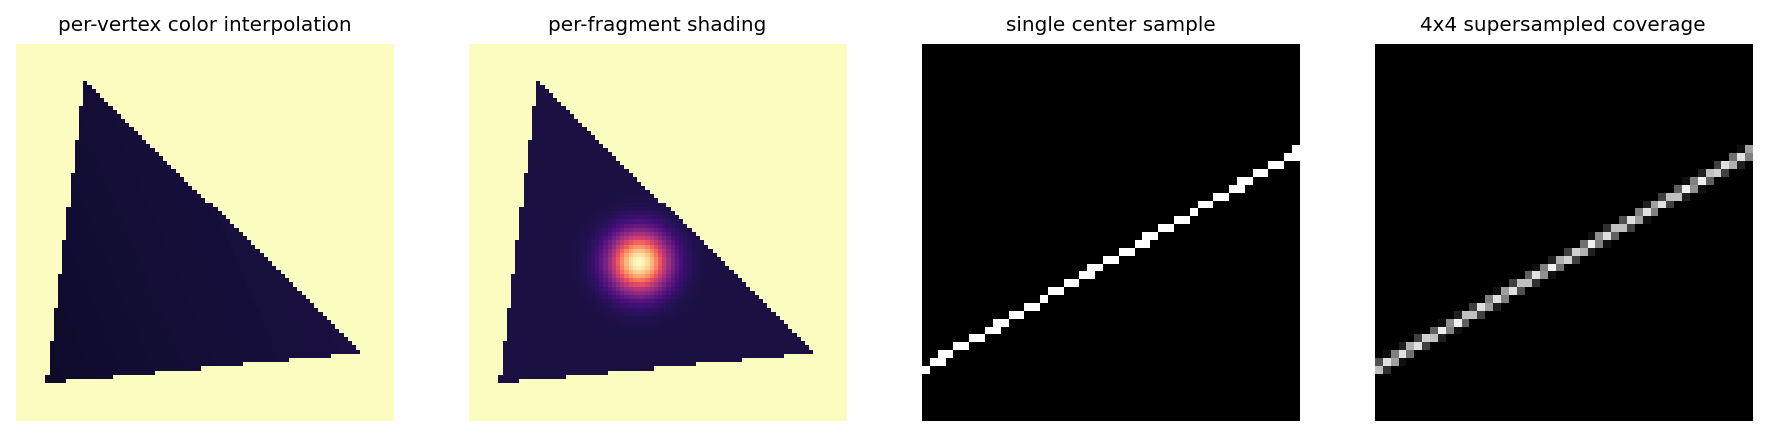

In [8]:
N = 90
yy, xx = np.mgrid[0:N, 0:N]
uv = np.dstack([(xx + 0.5) / N, (yy + 0.5) / N])
# A synthetic highlight centered inside the triangle. Vertex colors miss it.
tri_img = np.array([[0.08, 0.1], [0.92, 0.18], [0.18, 0.9]]) * N
pts_img = np.c_[xx.ravel()+0.5, yy.ravel()+0.5]
inside_img, w_img = inside_triangle(pts_img, tri_img)
inside_img = inside_img.reshape(N,N)
w_img = w_img.reshape(N,N,3)
vertex_intensity = np.array([0.08, 0.12, 0.10])
per_vertex = np.ones((N,N))
per_vertex[inside_img] = (w_img @ vertex_intensity)[inside_img]
center = np.array([0.45, 0.42])
highlight = 0.12 + 0.88 * np.exp(-np.sum((uv - center)**2, axis=-1) / 0.006)
per_fragment = np.ones((N,N))
per_fragment[inside_img] = highlight[inside_img]
checks["per_fragment_detects_hidden_highlight"] = bool(per_fragment[inside_img].max() > per_vertex[inside_img].max() + 0.5)

# Supersample a diagonal strip/line.
coarse = 48
sub = 4
Yc, Xc = np.mgrid[0:coarse, 0:coarse]
center_samples = np.abs((Yc + 0.5) - (0.58 * (Xc + 0.5) + 6.5)) < 0.55
coverage = np.zeros((coarse, coarse))
offsets = (np.arange(sub) + 0.5) / sub
for oy in offsets:
    for ox in offsets:
        coverage += (np.abs((Yc + oy) - (0.58 * (Xc + ox) + 6.5)) < 0.55)
coverage /= sub * sub
checks["supersampling_has_fractional_coverage"] = bool(np.any((coverage > 0) & (coverage < 1)))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, arr, title in zip(axes[:2], [per_vertex, per_fragment], ["per-vertex color interpolation", "per-fragment shading"]):
    ax.imshow(arr, origin="lower", cmap="magma", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
axes[2].imshow(center_samples, origin="lower", cmap="gray", vmin=0, vmax=1)
axes[2].set_title("single center sample", fontsize=9)
axes[2].axis("off")
axes[3].imshow(coverage, origin="lower", cmap="gray", vmin=0, vmax=1)
axes[3].set_title("4x4 supersampled coverage", fontsize=9)
axes[3].axis("off")
shade_path = remember(save_matplotlib(fig, UNIT, "shading-frequency-antialiasing.png"), "image")
plt.close(fig)
display_artifact(shade_path, width=900)


## Applied lab: culling decisions before expensive work

Culling is a performance decision: discard primitives or groups that cannot affect the framebuffer. View-volume culling is often conservative. A bounding sphere outside a clipping plane implies the object is outside, but an overlapping sphere does not prove the object is visible. Backface culling is different: for a closed, consistently oriented model, a triangle whose outward normal faces away from the eye will be hidden by front-facing parts.

The interactive lab plots signed distance from a sphere center to a clipping plane against radius. The red region is the safe reject region `distance > radius`; the gray band is uncertainty where the sphere overlaps the plane.


In [9]:
distances = np.linspace(-3, 4, 120)
radii = np.linspace(0.1, 2.5, 90)
D, R = np.meshgrid(distances, radii)
reject = D > R
fig_lab = go.Figure(data=[go.Surface(x=D, y=R, z=reject.astype(float), colorscale=[[0,"#e2e8f0"],[0.5,"#fbd38d"],[1,"#c53030"]])])
fig_lab.update_layout(
    title="Conservative view-plane culling: reject only when signed distance exceeds radius",
    scene=dict(xaxis_title="signed plane distance", yaxis_title="bounding radius", zaxis_title="reject flag"),
    height=560,
)
lab_path = remember(save_plotly_html(fig_lab, UNIT, "culling-decision-lab.html", include_plotlyjs=True), "html")
# Backface sign check with eye at origin looking along -z; CCW triangle in front has normal toward camera.
tri3 = np.array([[-0.5,-0.4,-3.0], [0.7,-0.3,-3.0], [0.1,0.8,-3.0]])
normal = np.cross(tri3[1]-tri3[0], tri3[2]-tri3[0])
view_vec = -tri3.mean(axis=0)
backface = np.dot(normal, view_vec) < 0
checks["sphere_cull_reject_region_nonempty"] = bool(np.any(reject))
checks["sphere_cull_overlap_not_rejected"] = bool(not reject[np.argmin(abs(radii-1.0)), np.argmin(abs(distances-0.2))])
checks["backface_test_front_triangle_not_rejected"] = not bool(backface)
display_artifact(lab_path, width="100%", height=560)


## Display the chapter artifacts

Every generated file below is concept-named and stored under `artifacts/chapter-09`. The artifact set is meant to be read as a miniature graphics pipeline: stage flow, raster grid, edge ownership, perspective-correct interpolation, clipping, z-buffering, sampling, and culling.


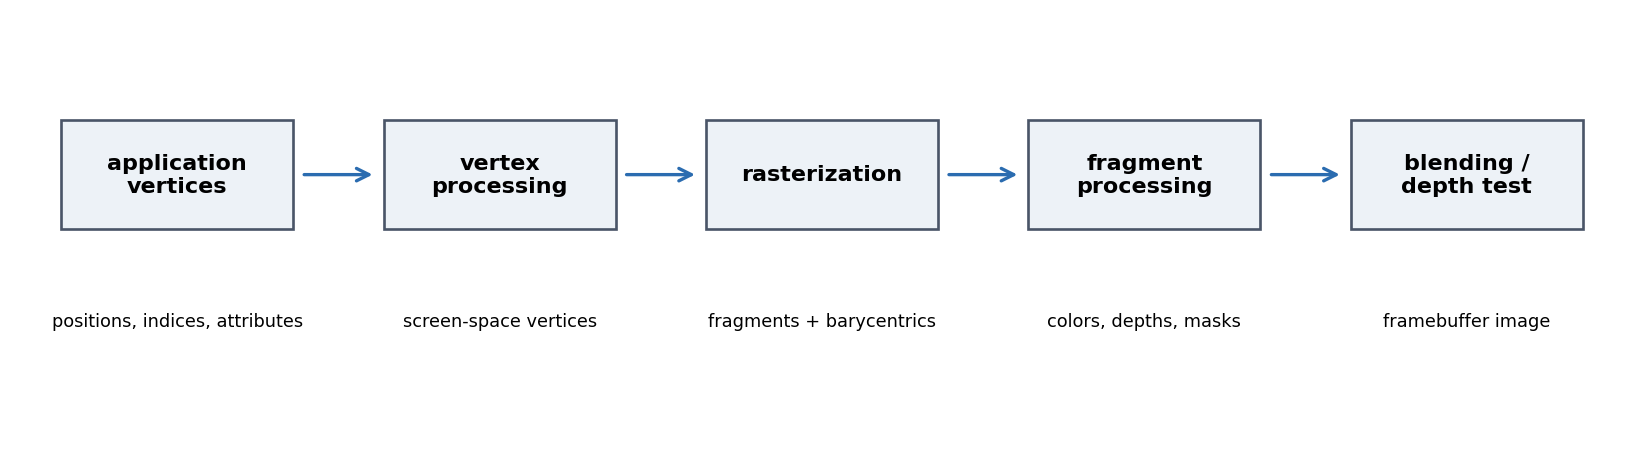

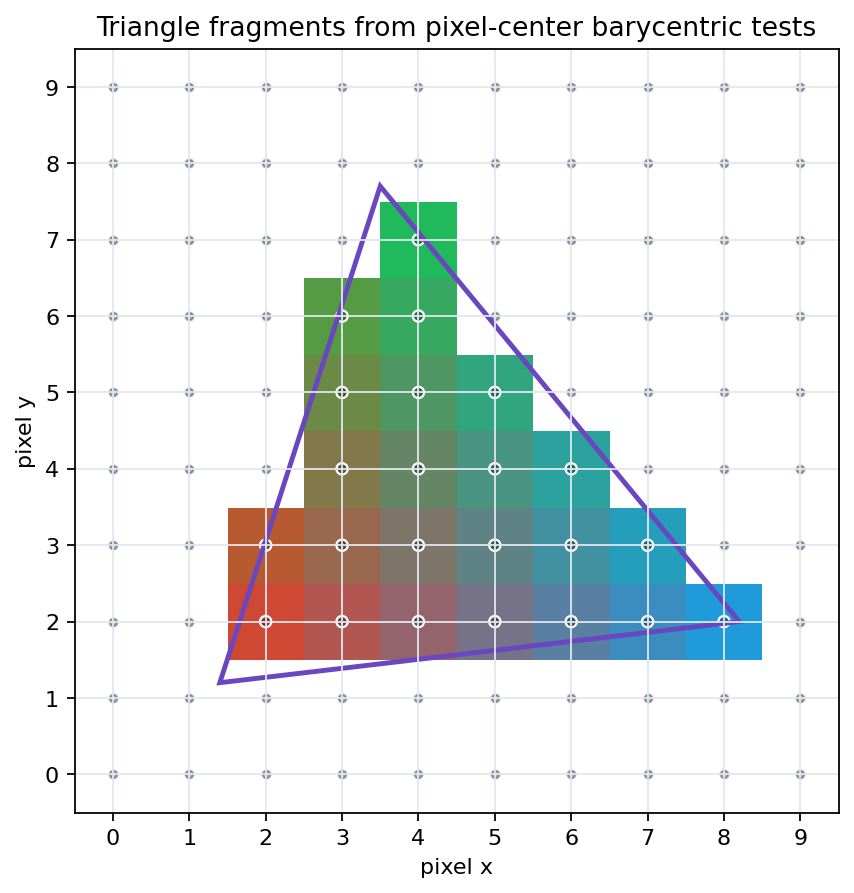

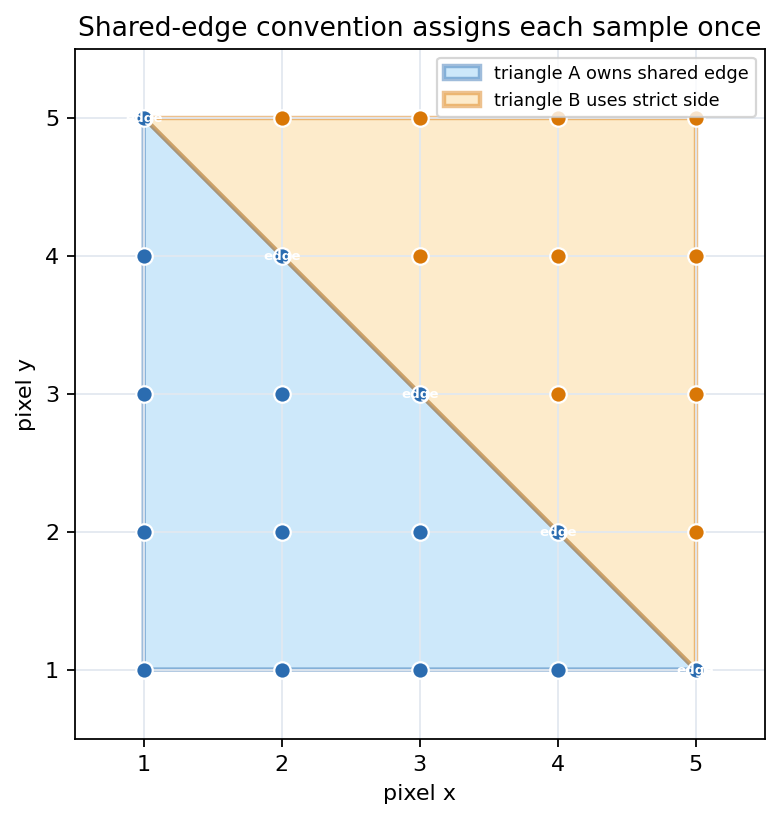

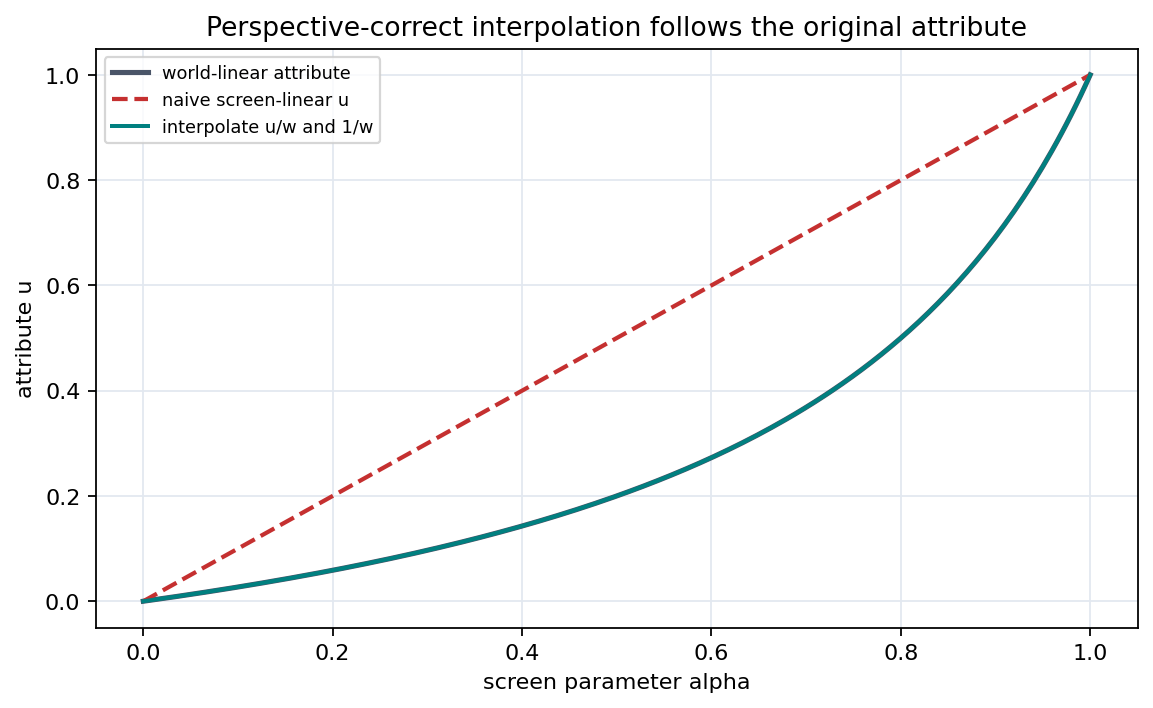

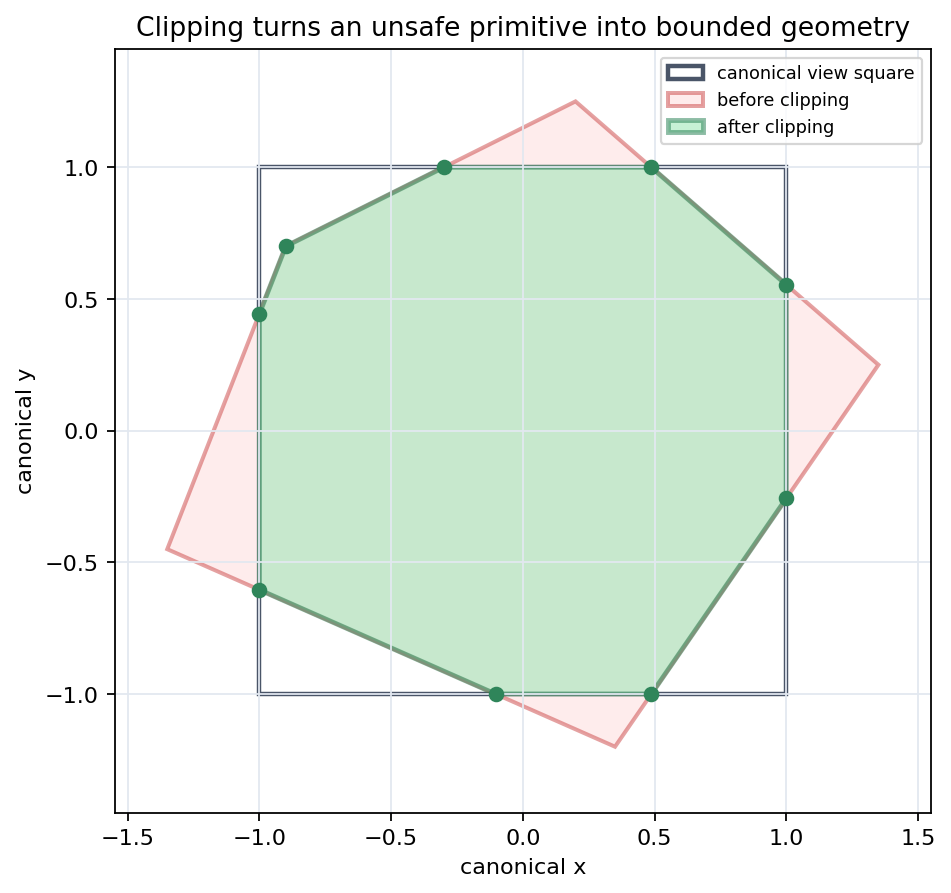

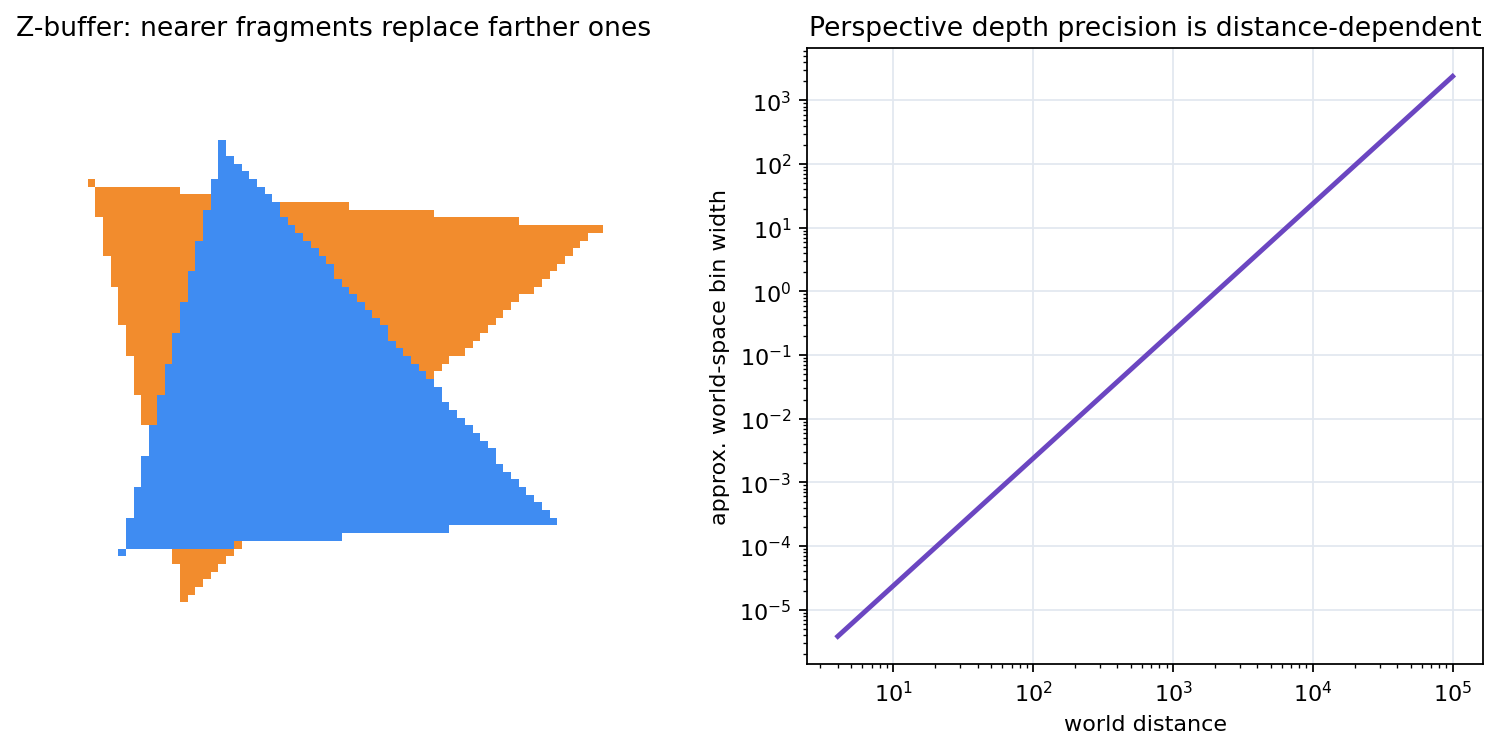

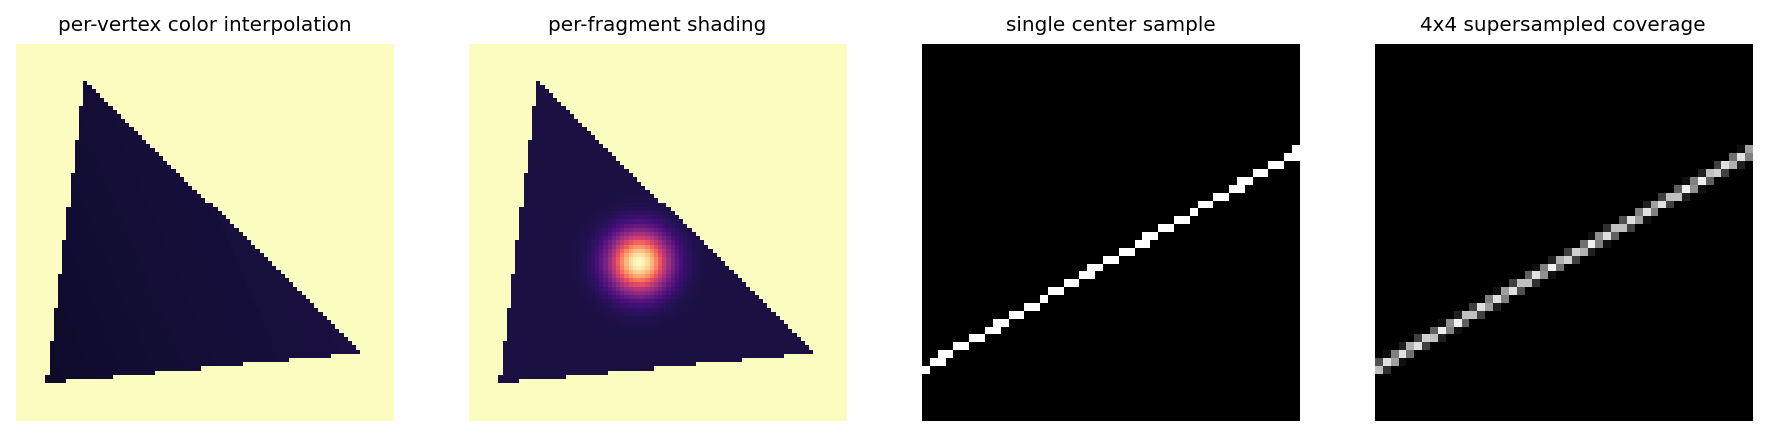

In [10]:
artifact_sequence = [*image_paths, *html_paths]
assert_artifacts(artifact_sequence)
for path in image_paths:
    display_artifact(path, width=760)
for path in html_paths:
    display_artifact(path, width="100%", height=560)


## Sanity checks

These checks target the chapter's implementation hazards. Rasterization must produce barycentric weights that sum to one. Edge rules must avoid holes and double draws. Perspective-correct interpolation must outperform naive screen-space interpolation. Clipped vertices must satisfy bounds. Z-buffering must make nearer fragments win. Supersampling must create fractional coverage. Culling must distinguish safe rejection from uncertain overlap.


In [11]:
assert checks["pipeline_stage_count"] == 5
assert checks["raster_fragment_count"] > 0
assert checks["barycentric_weight_sum_error"] < 1e-12
assert checks["barycentric_color_range_ok"] is True
assert checks["shared_edge_no_double_draws"] is True
assert checks["shared_edge_no_holes_in_square_samples"] is True
assert checks["perspective_correct_improves_error"] is True
assert checks["clipped_all_inside_unit_square"] is True
assert checks["zbuffer_front_wins_overlap"] is True
assert checks["zbuffer_bin_width_increases"] is True
assert checks["per_fragment_detects_hidden_highlight"] is True
assert checks["supersampling_has_fractional_coverage"] is True
assert checks["sphere_cull_reject_region_nonempty"] is True
assert checks["sphere_cull_overlap_not_rejected"] is True
assert checks["backface_test_front_triangle_not_rejected"] is True

image_records = [assert_nonblank_image(path) for path in image_paths]
artifact_records = assert_artifacts([*image_paths, *html_paths])
check_rows = [
    {"check": key, "value": str(value), "concept": "graphics pipeline invariant"}
    for key, value in sorted(checks.items())
]
table_path = remember(save_table_csv(check_rows, UNIT, "graphics-pipeline-check-ledger.csv"), "table")
storyboard = {
    "chapter": CHAPTER,
    "title": TITLE,
    "source_span": SOURCE_SPAN,
    "visuals": [rel_book(path) for path in image_paths + html_paths + [table_path]],
    "library_routing": {
        "numpy": "barycentric tests, z-buffer arrays, interpolation and sampling diagnostics",
        "matplotlib": "durable pipeline, raster, clipping, depth, and antialiasing figures",
        "plotly": "interactive culling decision surface",
    },
    "checks": checks,
}
storyboard_path = remember(save_json(storyboard, UNIT, "visual-storyboard.json"), "check")
checks_path = remember(save_json({"chapter": CHAPTER, "checks": checks, "image_records": image_records}, UNIT, "graphics-pipeline-invariants.json"), "check")
numeric_path = remember(save_json({"chapter": CHAPTER, "checks": checks}, UNIT, "numeric-checks.json"), "check")
final_report = {
    "chapter": CHAPTER,
    "title": TITLE,
    "printed_pages": "177-204",
    "pdf_pages": "194-221",
    "artifacts": [rel_book(path) for path in image_paths + html_paths + table_paths + check_paths],
    "nonblank_images": len(image_records),
    "checks": checks,
    "notebook_executed": True,
}
final_path = remember(save_json(final_report, UNIT, "final-sanity.json"), "check")
assert_artifacts([*check_paths, table_path])
display_artifact(final_path)
final_report


{'chapter': 9,
 'title': 'The Graphics Pipeline',
 'printed_pages': '177-204',
 'pdf_pages': '194-221',
 'artifacts': ['artifacts/chapter-09/figures/graphics-pipeline-stage-flow.png',
  'artifacts/chapter-09/figures/triangle-barycentric-raster-grid.png',
  'artifacts/chapter-09/figures/edge-ownership-shared-triangles.png',
  'artifacts/chapter-09/figures/perspective-correct-interpolation.png',
  'artifacts/chapter-09/figures/clipping-before-rasterization.png',
  'artifacts/chapter-09/figures/z-buffer-depth-precision.png',
  'artifacts/chapter-09/figures/shading-frequency-antialiasing.png',
  'artifacts/chapter-09/html/culling-decision-lab.html',
  'artifacts/chapter-09/tables/graphics-pipeline-check-ledger.csv',
  'artifacts/chapter-09/checks/visual-storyboard.json',
  'artifacts/chapter-09/checks/graphics-pipeline-invariants.json',
  'artifacts/chapter-09/checks/numeric-checks.json'],
 'nonblank_images': 7,
 'checks': {'pipeline_stage_count': 5,
  'pipeline_contracts_named': True,
  '

## Takeaways

- The graphics pipeline is a sequence of contracts between vertex data, primitives, fragments, and framebuffer state.
- Triangle rasterization is a barycentric computation over pixel centers, plus a deterministic rule for exact edge cases.
- Perspective-correct interpolation works because the quantities passed through the perspective transform are consistent homogeneous quantities.
- Clipping prevents invalid geometry from reaching rasterization, especially when a primitive crosses the eye plane.
- Z-buffering makes draw order less fragile, but perspective depth precision depends strongly on near/far choices.
- Per-fragment shading and supersampling are both sampling-rate decisions: one samples lighting more often, the other samples coverage more often.
- Culling is useful when a cheap conservative test saves more work than it costs.
